In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


import warnings
warnings.filterwarnings('ignore')

In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

In [3]:
# %cd /content/drive/MyDrive/Colab Notebooks/Project/

# ขั้นตอนการเตรียมข้อมูล

In [4]:
path = 'data/'

movies_item= ['movieId','title','genres']

rating_item= ['userId','movieId','rating','timestamp']

genres = [ 'Action' ,'Adventure','Animation','Children\'s','Comedy','Crime','Documentary','Drama','Fantasy','Film-Noir'
,'Horror','Musical','Mystery','Romance','Sci-Fi','Thriller','War','Western']

In [5]:
movies = pd.read_excel(path+'movies.xlsx', header=None, names=movies_item, skiprows=1 )

เปลี่ยนชื่อบาง column และลบcolumn ที่ไม่ได้ใช้งาน

In [6]:
rating = pd.read_excel(path+'ratings.xlsx', header=None, names=rating_item,skiprows=1 )

if 'rating' in rating.columns :
    rating = rating.rename({'rating':'user_rating'}, axis='columns')
    
if 'timestamp' in rating.columns :
    rating.drop(columns=['timestamp'],inplace=True)

In [7]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [8]:
rating.head()

,userId,movieId,user_rating
0,1,1,4
1,1,3,4
2,1,6,4
3,1,47,5
4,1,50,5


เช็คข้อมูลว่ามีข้อมูลที่เป็น Null หรือไม่

In [9]:
rating.isnull().sum()

userId         0
movieId        0
user_rating    0
dtype: int64

รวมตาราง rating กับ movie ด้วย movieId

In [10]:
rating_movie = rating.merge(movies, on='movieId')
rating_movie.head()

,userId,movieId,user_rating,title,genres
0,1,1,4,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,5,1,4,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
2,7,1,4,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
3,15,1,2,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
4,17,1,4,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy


ใส่ค่า mean เข้าไปใน ตาราง movies

In [11]:
mean_ratings = rating.groupby('movieId')['user_rating'].mean().reset_index()

if 'user_rating' in mean_ratings.columns :
    mean_ratings = mean_ratings.rename({'user_rating':'rating'}, axis='columns')

mean_ratings['rating'] = mean_ratings['rating'].round(2)
movie_ratings = pd.merge(movies, mean_ratings, on='movieId', how='left')
movie_ratings.head()

,movieId,title,genres,rating
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,3.90
1,2,Jumanji (1995),Adventure|Children|Fantasy,3.40
2,3,Grumpier Old Men (1995),Comedy|Romance,3.29
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,2.43
4,5,Father of the Bride Part II (1995),Comedy,3.06


# ลดค่า Bias ในข้อมูล

เป็นตาราง ที่จะนับจำนวนรีวิวที่แต่ละผู้ใช้ให้ไว้กับแต่ละหนัง 
(1คน โหวต หนังกี่เรื่อง)


In [12]:
users_ratings_count = rating_movie.groupby('userId').count()['movieId']
users_ratings_count = users_ratings_count.sort_values(ascending=False).reset_index()
users_ratings_count.rename(columns={'movieId':'No-of-Movies-Rated'}, inplace=True)
display(users_ratings_count.shape)
users_ratings_count.head()

(610, 2)

,userId,No-of-Movies-Rated
0,414,2698
1,599,2478
2,474,2108
3,448,1864
4,274,1346


จะเอาเฉพาะคนที่ดูหนังมากกว่า 30 เรื่อง

In [13]:
users_30 = users_ratings_count[users_ratings_count['No-of-Movies-Rated']>=30]
display(users_30.shape)

(501, 2)

In [14]:
movies_with_users_30 = pd.merge(users_30, rating_movie, on='userId')
display(movies_with_users_30.shape)
movies_with_users_30.head()

(98231, 6)

,userId,No-of-Movies-Rated,movieId,user_rating,title,genres
0,414,2698,1,4,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,414,2698,3,4,Grumpier Old Men (1995),Comedy|Romance
2,414,2698,6,3,Heat (1995),Action|Crime|Thriller
3,414,2698,47,4,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,414,2698,50,5,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [15]:
movies_ratings_count = rating_movie.groupby('title').count()['movieId'].sort_values(ascending=False).reset_index()
movies_ratings_count.rename(columns={'movieId':'Number-of-Movie-Ratings'}, inplace=True)
display(movies_ratings_count.shape)
movies_ratings_count.head()

(9719, 2)

,title,Number-of-Movie-Ratings
0,Forrest Gump (1994),329
1,"Shawshank Redemption, The (1994)",317
2,Pulp Fiction (1994),307
3,"Silence of the Lambs, The (1991)",279
4,"Matrix, The (1999)",278


จะเอาเฉพาะ หนังที่มีคนดูมากกว่า 5 ครั้ง

In [16]:
movies_ratings_10 = movies_ratings_count[movies_ratings_count['Number-of-Movie-Ratings']>=5]
display(movies_ratings_10.shape)
movies_ratings_10.head()

(3651, 2)

,title,Number-of-Movie-Ratings
0,Forrest Gump (1994),329
1,"Shawshank Redemption, The (1994)",317
2,Pulp Fiction (1994),307
3,"Silence of the Lambs, The (1991)",279
4,"Matrix, The (1999)",278


In [17]:
filtered_rating_movie = pd.merge(movies_with_users_30, movies_ratings_10, on='title')

if 'No-of-Movies-Rated' in filtered_rating_movie.columns :
    filtered_rating_movie.drop(columns=['No-of-Movies-Rated'],inplace=True)
    filtered_rating_movie.drop(columns=['Number-of-Movie-Ratings'],inplace=True)

filtered_rating_movie.head()

,userId,movieId,user_rating,title,genres
0,414,1,4,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,599,1,3,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
2,474,1,4,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
3,448,1,5,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
4,274,1,4,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy


แปลงข้อมูลให้อยู่ในรูปแบบที่เหมาะสมก่อนที่จะนำมาทำ PCA

In [18]:

# user_movies = pd.crosstab(rating_movie['userId'], rating_movie['title'])
# user_movies = pd.crosstab(filtered_rating_movie['userId'], filtered_rating_movie['title'])

user_movies = filtered_rating_movie.pivot_table(index='userId',columns='title', values='user_rating')
user_movies.fillna(0, inplace=True)

user_movies.head()

title,"'burbs, The (1989)",(500) Days of Summer (2009),*batteries not included (1987),10 Cloverfield Lane (2016),10 Things I Hate About You (1999),"10,000 BC (2008)",101 Dalmatians (1996),101 Dalmatians (One Hundred and One Dalmatians) (1961),102 Dalmatians (2000),12 Angry Men (1957),...,Zero Effect (1998),Zodiac (2007),Zombieland (2009),Zoolander (2001),Zootopia (2016),[REC] (2007),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),ยกThree Amigos! (1986)
userId,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# ลดมิติของข้อมูล

1. from sklearn.decomposition import PCA: นำเข้าคลาส PCA จากโมดูล sklearn.decomposition เพื่อใช้ในการทำ Principal Component Analysis (PCA).

2. pca = PCA(n_components=2): สร้างอ็อบเจ็กต์ PCA โดยกำหนดพารามิเตอร์ n_components=2 เพื่อกำหนดให้ PCA สร้าง Principal Components 2 ตัวแปร.

3. pca.fit(user_movies): ทำการฝึกสอน PCA โดยใช้ข้อมูล user_movies เพื่อหา Principal Components ที่เหมาะสมสำหรับข้อมูล.

4. pca_samples = pca.transform(user_movies): ทำการแปลงข้อมูล user_movies โดยใช้ PCA ที่ได้ฝึกสอนไว้ และสร้างข้อมูลที่ลดมิติแล้ว (principal components) ในตัวแปร pca_samples.

5. ps = pd.DataFrame(pca_samples): สร้าง DataFrame จากข้อมูลที่ลดมิติแล้ว (principal components) ในตัวแปร pca_samples และเก็บในตัวแปร ps.

6. tocluster = pd.DataFrame(ps): สร้าง DataFrame ใหม่ที่มีข้อมูลเป็นตัวแปร ps และเก็บในตัวแปร tocluster.

โค้ดนี้ใช้ PCA เพื่อลดมิติของข้อมูล user_movies ลงเหลือ 2 มิติ และสร้าง DataFrame tocluster ที่เก็บข้อมูลที่ลดมิติแล้ว ซึ่งใช้ในการจัดกลุ่มหรือวิเคราะห์ข้อมูลเพิ่มเติมต่อไปได้ตามความต้องการ

In [77]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
pca.fit(user_movies)
pca_samples = pca.transform(user_movies)

ps = pd.DataFrame(pca_samples)
tocluster = pd.DataFrame(ps)

In [78]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X_train = user_movies.values

scores = []
inertia_list = np.empty(11)

# min max n_clusters
min_n = 2
max_n = 11

for i in range(min_n, max_n):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(tocluster)
    inertia_list[i] = kmeans.inertia_
    scores.append(silhouette_score(tocluster, kmeans.labels_))

ค่า kmeans.inertia_ มีความหมายว่ายิ่งมีค่าน้อยกว่ายิ่งดี เนื่องจากแสดงถึงความใกล้เคียงระหว่างจุดข้อมูลและจุดศูนย์กลางในแต่ละกลุ่ม โดยค่า kmeans.inertia_ จะนำมาใช้ในการเลือกจำนวนกลุ่มที่เหมาะสม

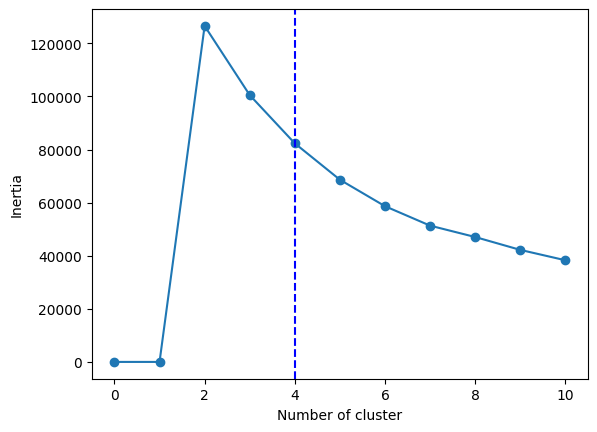

In [79]:
plt.plot(range(0,max_n),inertia_list,'-o')
plt.xlabel('Number of cluster')
plt.axvline(x=4, color='blue', linestyle='--')
plt.ylabel('Inertia')
plt.show()

ค่า Silhouette Score ที่ดีสำหรับการจัดกลุ่ม (clustering) คือค่าที่เข้าใกล้ 1 หรือมีค่าใกล้เคียง 1 มากที่สุด

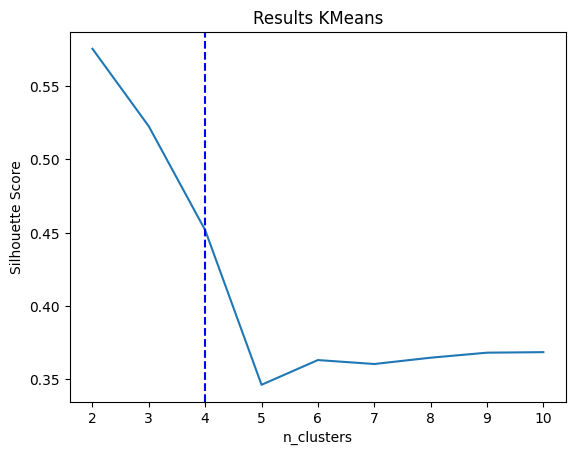

[0.5754611994201675,
 0.5225581028143108,
 0.45175677644047446,
 0.34627690934548977,
 0.3631385105168153,
 0.3604468196929825,
 0.3647459072359188,
 0.3681759982739932,
 0.3685310925778261]

In [80]:
plt.plot(range(min_n,max_n), scores);
plt.title('Results KMeans')
plt.xlabel('n_clusters');
plt.axvline(x=4, color='blue', linestyle='--')
plt.ylabel('Silhouette Score');
plt.show()
scores

# สร้าง Model จาก KMeans

In [81]:
from sklearn.cluster import KMeans

clusterer = KMeans(n_clusters=4,random_state=30).fit(tocluster)

Save Model

In [82]:
import joblib

joblib.dump(clusterer, 'models/kmeans_model.pkl')

['models/kmeans_model.pkl']

Load Model

In [83]:
clusterer = joblib.load('models/kmeans_model.pkl')

In [84]:
centers = clusterer.cluster_centers_
# print(centers)

c_preds = clusterer.predict(tocluster)

user_movies['cluster'] = c_preds


user_movies.head(10)

title,"'burbs, The (1989)",(500) Days of Summer (2009),*batteries not included (1987),10 Cloverfield Lane (2016),10 Things I Hate About You (1999),"10,000 BC (2008)",101 Dalmatians (1996),101 Dalmatians (One Hundred and One Dalmatians) (1961),102 Dalmatians (2000),12 Angry Men (1957),...,Zodiac (2007),Zombieland (2009),Zoolander (2001),Zootopia (2016),[REC] (2007),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),ยกThree Amigos! (1986),cluster
userId,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,3
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


Clustering 4 กลุ่ม

In [85]:
c0 = user_movies[user_movies['cluster']==0].drop('cluster',axis=1).mean()
c1 = user_movies[user_movies['cluster']==1].drop('cluster',axis=1).mean()
c2 = user_movies[user_movies['cluster']==2].drop('cluster',axis=1).mean()
c3 = user_movies[user_movies['cluster']==3].drop('cluster',axis=1).mean()

แสดง Top 10 หนังในแต่ละกลุ่ม

กลุ่มที่1

In [86]:
c0.sort_values(ascending=False)[0:10]

title
Matrix, The (1999)                                           3.559524
Forrest Gump (1994)                                          3.392857
Shawshank Redemption, The (1994)                             3.321429
Fight Club (1999)                                            3.142857
Lord of the Rings: The Return of the King, The (2003)        3.095238
Lord of the Rings: The Two Towers, The (2002)                3.047619
Lord of the Rings: The Fellowship of the Ring, The (2001)    3.023810
Dark Knight, The (2008)                                      2.833333
Star Wars: Episode IV - A New Hope (1977)                    2.773810
Shrek (2001)                                                 2.738095
dtype: float64

กลุ่มที่ 2

In [87]:
c1.sort_values(ascending=False)[0:10]

title
Shawshank Redemption, The (1994)     2.143695
Forrest Gump (1994)                  1.997067
Pulp Fiction (1994)                  1.976540
Silence of the Lambs, The (1991)     1.850440
Braveheart (1995)                    1.548387
Schindler's List (1993)              1.381232
Jurassic Park (1993)                 1.351906
Matrix, The (1999)                   1.346041
Apollo 13 (1995)                     1.284457
Terminator 2: Judgment Day (1991)    1.266862
dtype: float64

กลุ่มที่ 3

In [88]:
c2.sort_values(ascending=False)[0:10]

title
Matrix, The (1999)                                           4.259259
Star Wars: Episode IV - A New Hope (1977)                    4.222222
Star Wars: Episode V - The Empire Strikes Back (1980)        4.222222
Star Wars: Episode VI - Return of the Jedi (1983)            4.148148
Seven (a.k.a. Se7en) (1995)                                  3.962963
Forrest Gump (1994)                                          3.925926
Back to the Future (1985)                                    3.925926
Kill Bill: Vol. 1 (2003)                                     3.888889
Lord of the Rings: The Fellowship of the Ring, The (2001)    3.888889
Shawshank Redemption, The (1994)                             3.888889
dtype: float64

กลุ่มที่ 4

In [89]:
c3.sort_values(ascending=False)[0:10]

title
Star Wars: Episode IV - A New Hope (1977)                                         4.08
Star Wars: Episode V - The Empire Strikes Back (1980)                             3.92
Pulp Fiction (1994)                                                               3.84
Raiders of the Lost Ark (Indiana Jones and the Raiders of the Lost Ark) (1981)    3.82
Silence of the Lambs, The (1991)                                                  3.68
Fargo (1996)                                                                      3.64
Matrix, The (1999)                                                                3.58
Forrest Gump (1994)                                                               3.58
Star Wars: Episode VI - Return of the Jedi (1983)                                 3.54
Godfather, The (1972)                                                             3.46
dtype: float64

In [90]:
def createMovieInfoList(movielist):
    genre_list = list()
    rating_list= list()
    for x in movies['title']:
        if x in movielist:
            rating_list.append(movie_ratings[movie_ratings['title']==x].rating.values.astype(int))
            # for y in movie_ratings[movie_ratings['title']==x].genres.values:
            #      genre_list.append(y)
            genre_list.append(movie_ratings[movie_ratings['title']==x].genres.values)
    # print(len(genre_list))
    # print(len(rating_list))
    return genre_list,rating_list

In [91]:
def count_word(df, ref_col, liste):
    keyword_count = dict()
    for s in liste: keyword_count[s] = 0

    # for liste_keywords in df[ref_col].str.split('|'):        
    #     if type(liste_keywords) == float and pd.isnull(liste_keywords): continue        
    #     for s in [s for s in liste_keywords if s in liste]: 
    #         if pd.notnull(s): keyword_count[s] += 1
    
    for i in range(len(df[ref_col])):
        liste_keywords = df[ref_col][i][0].split('|')
        
        if type(liste_keywords) == float and pd.isnull(liste_keywords): continue
        for s in [s for s in liste_keywords if s in liste]: 
            if pd.notnull(s): keyword_count[s] += 1

    #______________________________________________________________________
    # convert the dictionary in a list to sort the keywords by frequency
    keyword_occurences = []
    for k,v in keyword_count.items():
        keyword_occurences.append([k,v])
    keyword_occurences.sort(key = lambda x:x[1], reverse = True)
    return keyword_occurences, keyword_count

In [92]:
from wordcloud import WordCloud

def makeCloud(Dict, name, color):
    words = dict()

    for s in Dict:
        words[s[0]] = s[1]

    wordclouds = WordCloud(
        width=1500,
        height=500,
        background_color=color,
        max_words=20,
        max_font_size=500,
        normalize_plurals=False
    )
    wordclouds.generate_from_frequencies(words)

    fig = plt.figure(figsize=(12, 8))
    plt.title(name)
    plt.imshow(wordclouds)
    plt.axis('off')

    plt.show()

In [93]:
def display_info(cluster,  cluster_id):
    movielist = list(cluster.index)

    data = pd.DataFrame()
    data['genres'],data['user_rating'] =  createMovieInfoList(movielist)

    set_keywords = set()
    for i in range(len(data['genres'])):
        liste_keywords = data['genres'][i][0].split('|')

        for j in liste_keywords:
            if isinstance(liste_keywords, float): continue  # only happen if liste_keywords = NaN
            set_keywords = set_keywords.union(liste_keywords)

    cluster_animelist = list(cluster.sort_values(ascending=False)[0:10].index)
    cluster_data = pd.DataFrame()
    cluster_data['genres'],cluster_data['user_rating'] =  createMovieInfoList(cluster_animelist)
    cluster_data.iloc[:,1:4] = cluster_data.iloc[:,1:4].astype(int) # change to numeric object to integer
    keyword_occurences, dum = count_word(cluster_data, 'genres', set_keywords)

    makeCloud(keyword_occurences[0:10],f"cluster {cluster_id}","lemonchiffon")
    print(keyword_occurences[0:5])
    print('cluster 0: \nAVG movie rating : {0}'
        .format(cluster_data['user_rating'].mean()))

# สรุปข้อมูล Clustering แต่ละกลุ่ม

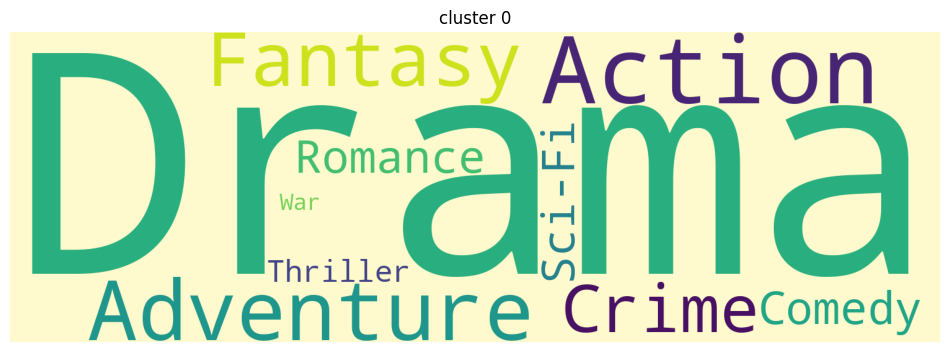

[['Drama', 5], ['Action', 5], ['Adventure', 5], ['Fantasy', 4], ['Crime', 3]]
cluster 0: 
AVG movie rating : 3.9


In [94]:
display_info(c0, 0)

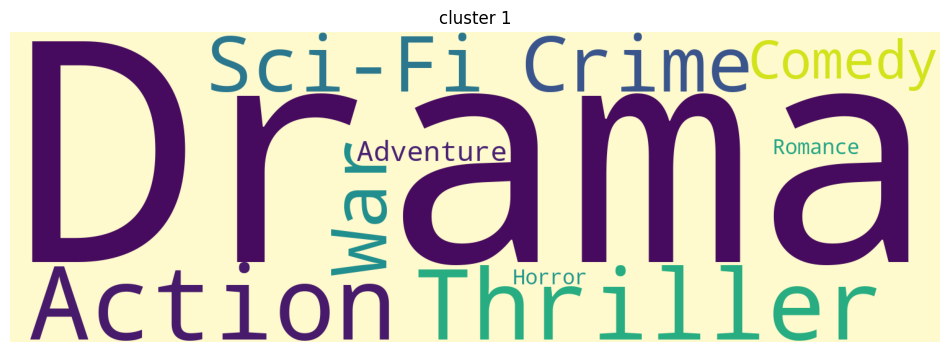

[['Drama', 6], ['Action', 4], ['Thriller', 4], ['Crime', 3], ['War', 3]]
cluster 0: 
AVG movie rating : 3.7


In [95]:
display_info(c1, 1)

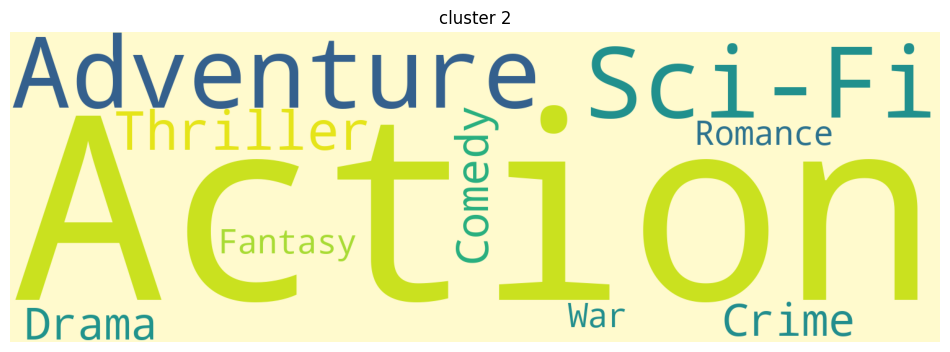

[['Action', 5], ['Adventure', 5], ['Sci-Fi', 5], ['Thriller', 3], ['Crime', 2]]
cluster 0: 
AVG movie rating : 3.8


In [96]:
display_info(c2, 2)

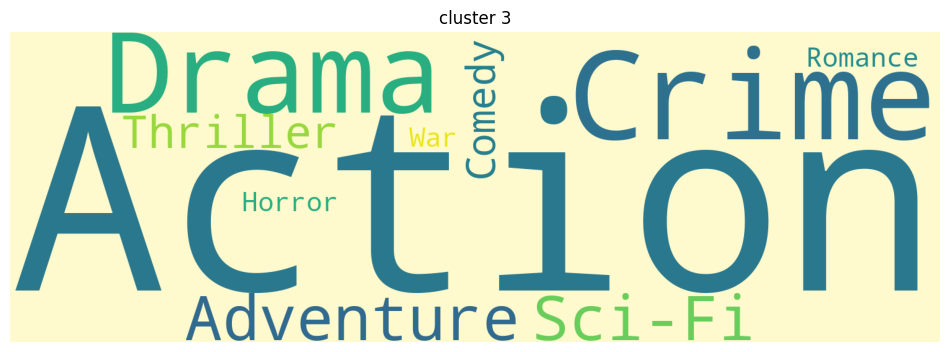

[['Action', 5], ['Crime', 4], ['Drama', 4], ['Adventure', 4], ['Sci-Fi', 4]]
cluster 0: 
AVG movie rating : 4.0


In [97]:
display_info(c3, 3)

# ทดสอบการจัดกลุ่ม

โดยการเพิ่ม user คนใหม่เข้าไป

In [98]:
test_rating = pd.read_excel(path+'test_rating.xlsx', header=None, names=rating_item,skiprows=1 )
if 'rating' in test_rating.columns :
    test_rating = test_rating.rename({'rating':'user_rating'}, axis='columns')
if 'timestamp' in test_rating.columns :
    test_rating.drop(columns=['timestamp'],inplace=True)
test_rating.head()

,userId,movieId,user_rating
0,9999,1,4
1,9999,3,4
2,9999,6,4
3,9999,47,5
4,9999,50,5


In [99]:
test_rating_movie = test_rating.merge(movies, on='movieId')
test_rating_movie.head()

,userId,movieId,user_rating,title,genres
0,9999,1,4,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,9999,3,4,Grumpier Old Men (1995),Comedy|Romance
2,9999,6,4,Heat (1995),Action|Crime|Thriller
3,9999,47,5,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,9999,50,5,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [100]:
filtered_rating_movie = filtered_rating_movie.append(test_rating_movie, ignore_index=True)
filtered_rating_movie[filtered_rating_movie['userId'] == 9999].head()

,userId,movieId,user_rating,title,genres
87781,9999,1,4,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
87782,9999,3,4,Grumpier Old Men (1995),Comedy|Romance
87783,9999,6,4,Heat (1995),Action|Crime|Thriller
87784,9999,47,5,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
87785,9999,50,5,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [101]:
user_movies = filtered_rating_movie.pivot_table(index='userId',columns='title', values='user_rating')
user_movies.fillna(0, inplace=True)

user_movies.tail()

title,"'burbs, The (1989)",(500) Days of Summer (2009),*batteries not included (1987),10 Cloverfield Lane (2016),10 Things I Hate About You (1999),"10,000 BC (2008)",101 Dalmatians (1996),101 Dalmatians (One Hundred and One Dalmatians) (1961),102 Dalmatians (2000),12 Angry Men (1957),...,Zero Effect (1998),Zodiac (2007),Zombieland (2009),Zoolander (2001),Zootopia (2016),[REC] (2007),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),ยกThree Amigos! (1986)
userId,,,,,,,,,,,,,,,,,,,,,
607,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
608,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.0,0.0,0.0,4.0,4.0,0.0,0.0
609,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
610,0.0,4.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,5.0,4.0,4.0,4.0,4.0,0.0,2.0,2.0,0.0
9999,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [102]:
pca = PCA(n_components=2)
pca.fit(user_movies)
pca_samples = pca.transform(user_movies)

ps = pd.DataFrame(pca_samples)
tocluster = pd.DataFrame(ps)

In [103]:
c_preds = clusterer.predict(tocluster)

user_movies['cluster'] = c_preds


user_movies.tail(10)

ValueError: X has 2 features, but KMeans is expecting 3 features as input.

User_ID ที่ 9999 อยู่ใน cluster 1